In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

In [ ]:
from utils import DataHandler
from ESN import ESNetwork
from reservoirs import CPRC
from circuits import CPCircuit

In [54]:
def compute_memory_capacity_explicit(reservoir_states, input_signal, max_delay=50, ridge_alpha=1e-6):
    """
    Computes memory capacity based on the explicit definition from arXiv:2403.08998.

    Parameters:
        reservoir_states (np.ndarray): Reservoir states of shape (T, N)
        input_signal (np.ndarray): Original input signal (1D array of length T)
        max_delay (int): Maximum delay to compute memory for
        ridge_alpha (float): Regularization strength for Ridge regression

    Returns:
        total_memory_capacity (float): Sum of per-delay memory scores
        memory_scores (list): List of memory capacity C^τ_STM per delay
    """
    memory_scores = []

    for tau in range(1, max_delay + 1):
        X = reservoir_states[tau:]
        y_target = input_signal[:-tau]

        # Train readout
        model = Ridge(alpha=ridge_alpha)
        model.fit(X, y_target)
        y_pred = model.predict(X)

        cov = np.cov(y_pred, y_target, bias=True)[0, 1]
        var_pred = np.var(y_pred)
        var_target = np.var(y_target)

        c_tau = (cov ** 2) / (var_pred * var_target) if var_pred > 0 and var_target > 0 else 0.0
        memory_scores.append(c_tau)

    total_memory_capacity = np.sum(memory_scores)
    return total_memory_capacity, memory_scores

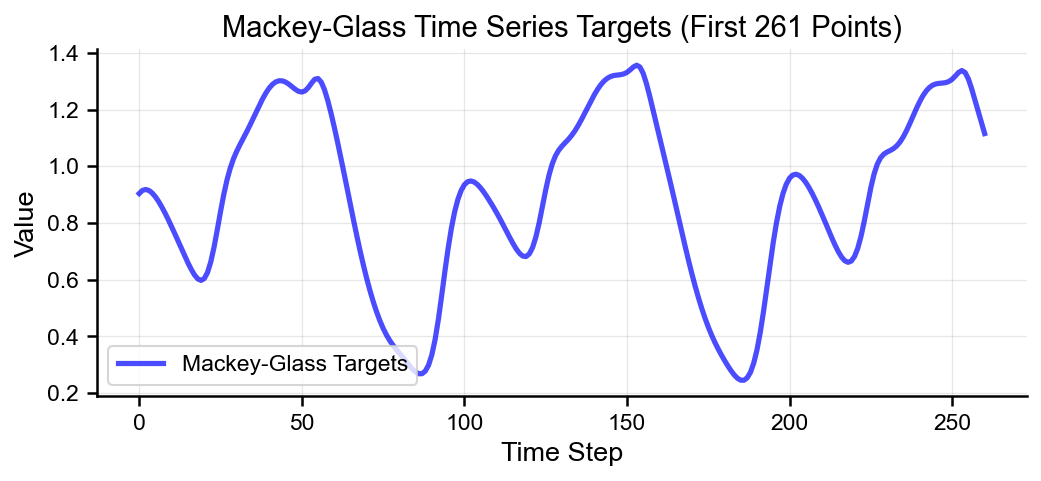

In [58]:
window_size = 20 #20
n_samples = 300
tau =28
X, Y = DataHandler().load_dataset('mackey_glass', n_samples = n_samples, tau = tau, time_step=1, window_size=window_size,prediction_horizon=20, plot=True, min_plot_points=1000)

In [42]:
tr = 0.75
train_size = int(n_samples*tr)  # Training set size
# Split into training and testing sets
X_train_, X_test_ = X[:train_size], X[train_size:]
y_train, y_test = Y[:train_size], Y[train_size:]

In [43]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_)
X_test = scaler.transform(X_test_) 

In [ ]:
import numpy as np
from sklearn.metrics import mutual_info_score
def compute_excess_entropy(data, window_size=10, max_lag=20, bins=20):
    E_values = []
    hist_bins = np.histogram_bin_edges(data, bins=bins)

    for lag in range(1, max_lag + 1):
        past_labels, future_labels = [], []

        for i in range(len(data) - 2 * window_size - lag):
            past = np.digitize(data[i : i + window_size], hist_bins)
            future = np.digitize(data[i + window_size + lag : i + 2 * window_size + lag], hist_bins)

            # Convert to tuple of ints (hashable)
            past_labels.append(tuple(past))
            future_labels.append(tuple(future))


        past_labels_str = [str(p) for p in past_labels]
        future_labels_str = [str(f) for f in future_labels]

        mi = mutual_info_score(past_labels_str, future_labels_str)
        E_values.append(mi)

    return E_values


compute_excess_entropy(X_train, window_size=20)

[np.float64(8.894688149871843),
 np.float64(8.894179298950384),
 np.float64(8.893670329533872),
 np.float64(8.893161241577037),
 np.float64(8.89265203503459),
 np.float64(8.892142709861217),
 np.float64(8.891633266011585),
 np.float64(8.891309733279442),
 np.float64(8.890986131714488),
 np.float64(8.890662461291413),
 np.float64(8.890338721984921),
 np.float64(8.890014913769663),
 np.float64(8.889691036620317),
 np.float64(8.889367090511524),
 np.float64(8.88904307541792),
 np.float64(8.888718991314127),
 np.float64(8.88839483817475),
 np.float64(8.888070615974389),
 np.float64(8.887746324687631),
 np.float64(8.887421964289032)]

In [7]:
itr = 50
a= -1.4746251231135765
b = 1.47
vals = np.linspace(a,b,itr)

In [8]:
qstates =[]
MC = []
R2 = []
entropies = []
mserror = []
for i in range(itr):
    dim=len(X_train[0])
    CP_params = [vals[i], np.pi/7, -np.pi/3, 7*np.pi/7,np.pi/9, -np.pi/7]
    cprc1 = CPRC(dim=dim, execution_mode='simulation', CP_params=CP_params, kernel = True) #simulation
    esn1 = ESNetwork(
        reservoir=cprc1, 
        dim=dim, 
        regularization=1e-6, 
        alpha=1, 
        show_progress=True, 
        approach='feedback', # 'feedback', or 'time-multiplexing'
        model_type='ridge',  # Options: 'ridge', 'lasso', 'linear', 'svr', 'svc'
        limit = 0.6,
        cpk=True)

    cprc2 = CPRC(dim=dim, execution_mode='entropy', CP_params=CP_params, kernel = True) #simulation
    esn2 = ESNetwork(
        reservoir=cprc2, 
        dim=dim, 
        regularization=1e-6, 
        alpha=1, 
        show_progress=True, 
        approach='feedback', # 'feedback', or 'time-multiplexing'
        model_type='ridge',  # Options: 'ridge', 'lasso', 'linear', 'svr', 'svc'
        limit = 0.6,
        cpk=True,
    entropy=True)
    esn1.fit(X_train, y_train)
    predictions = esn1.predict(X_test)
    rmse = mean_squared_error(y_test, predictions)
    mserror.append(rmse)
    
    ent = esn2.fit(X_train, y_train)
    entropies.append(ent)
    quantum_states = esn1.get_saved_states()
    qstates.append(quantum_states)
    memory_capacity, r2_scores = compute_memory_capacity_explicit(quantum_states, y_train)
    MC.append(memory_capacity)
    R2.append(r2_scores)

Training Progress: 100%|█████████| 7500/7500 [07:28<00:00, 16.73 sample/s]


Average entropy per qubit vs rest:
Qubit 0: 0.3067
Qubit 1: 0.3957
Qubit 2: 0.5069
Qubit 3: 0.5226
Qubit 4: 0.5408
Qubit 5: 0.6083
Qubit 6: 0.5983
Qubit 7: 0.6167
Qubit 8: 0.6520
Qubit 9: 0.6627
Qubit 10: 0.6375
Qubit 11: 0.6193


Training Progress: 100%|█████████| 7500/7500 [07:10<00:00, 17.43 sample/s]


Average entropy per qubit vs rest:
Qubit 0: 0.2969
Qubit 1: 0.3837
Qubit 2: 0.4969
Qubit 3: 0.5123
Qubit 4: 0.5331
Qubit 5: 0.6001
Qubit 6: 0.5897
Qubit 7: 0.6076
Qubit 8: 0.6478
Qubit 9: 0.6566
Qubit 10: 0.6310
Qubit 11: 0.6175


Training Progress: 100%|█████████| 7500/7500 [07:16<00:00, 17.18 sample/s]


...

Average entropy per qubit vs rest:
Qubit 0: 0.3727
Qubit 1: 0.4480
Qubit 2: 0.5403
Qubit 3: 0.5620
Qubit 4: 0.6011
Qubit 5: 0.6557
Qubit 6: 0.6558
Qubit 7: 0.6730
Qubit 8: 0.6932
Qubit 9: 0.6983
Qubit 10: 0.6569
Qubit 11: 0.6112


Training Progress: 100%|█████████| 7500/7500 [07:09<00:00, 17.47 sample/s]


Average entropy per qubit vs rest:
Qubit 0: 0.3592
Qubit 1: 0.4396
Qubit 2: 0.5356
Qubit 3: 0.5583
Qubit 4: 0.5906
Qubit 5: 0.6524
Qubit 6: 0.6470
Qubit 7: 0.6624
Qubit 8: 0.6848
Qubit 9: 0.6937
Qubit 10: 0.6532
Qubit 11: 0.6006


Training Progress: 100%|█████████| 7500/7500 [07:14<00:00, 17.26 sample/s]


Average entropy per qubit vs rest:
Qubit 0: 0.3461
Qubit 1: 0.4305
Qubit 2: 0.5304
Qubit 3: 0.5533
Qubit 4: 0.5806
Qubit 5: 0.6484
Qubit 6: 0.6377
Qubit 7: 0.6514
Qubit 8: 0.6764
Qubit 9: 0.6887
Qubit 10: 0.6490
Qubit 11: 0.5918


In [9]:
import pickle
with open("results.pkl", "wb") as f:
    pickle.dump({
        "qstates": qstates,
        "MC": MC,
        "R2": R2,
        "MSE": mserror,
        "entropies": entropies
    }, f)

In [26]:
import numpy as np
itr = 50
a = -1.4746251231135765
b=1.47
vals = np.linspace(a,b,itr)
np.arange(len(MC))

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [25]:
import pickle

with open("results_alpha_0_1.pkl", "rb") as f:
    data = pickle.load(f)

qstates = data["qstates"]
MC = data["MC"]
R2 = data["R2"]
entropies = data["entropies"]
rmse = data["MSE"]

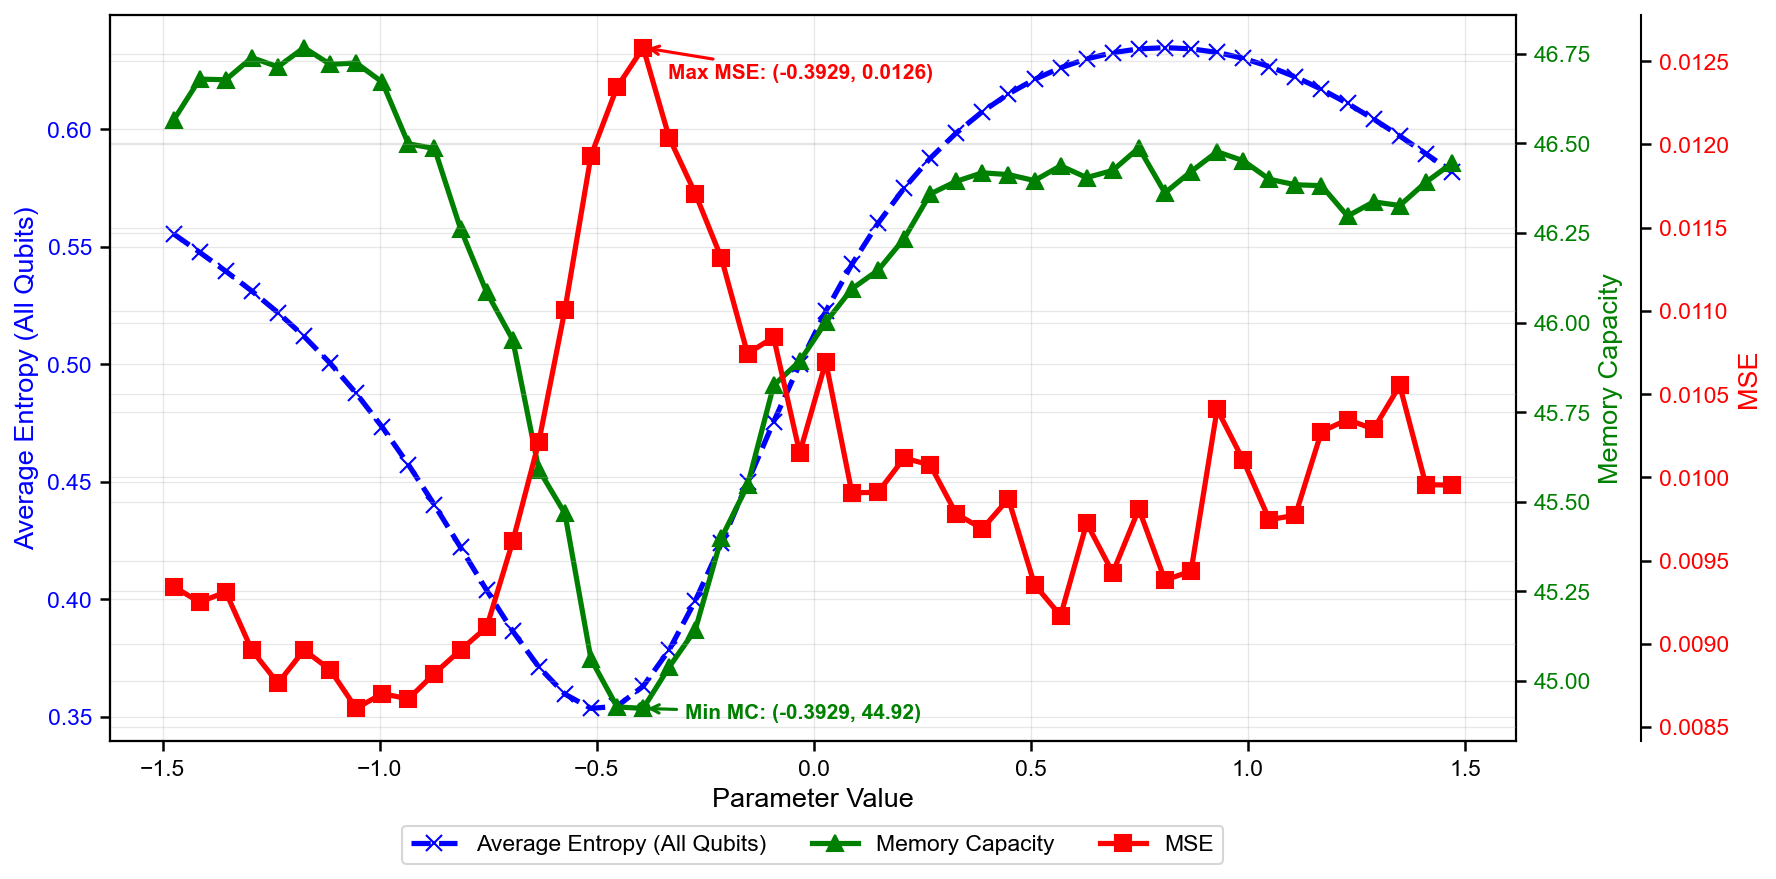

In [50]:
import numpy as np
import matplotlib.pyplot as plt

PARAM_RANGE = (-1.4746251231135765, 1.47)

def _annotate_point(ax, x_val, y_val, label, color, text_offset=(12, -15), rad=0.0):
    """Add a dot + arrow annotation to an axis."""
    ax.plot(x_val, y_val, 'o', color=color, markersize=6, zorder=5)
    ax.annotate(
        label,
        xy=(x_val, y_val),
        xytext=text_offset,
        textcoords='offset points',
        arrowprops=dict(arrowstyle="->", color=color, lw=1.5,
                        connectionstyle=f"arc3,rad={rad}"),
        fontsize=10, color=color, fontweight='bold'
    )

def plot_mc_entropy_rmse_avg(MC, entropies, mse, qubit_index=0):
    MC = np.array(MC)
    mse = np.array(mse)

    if len(MC) != len(mse) != len(entropies):
        raise ValueError("MC, mse, and entropies must have the same length.")

    avg_entropy_values = np.array([np.mean(list(e.values())) for e in entropies])
    x = np.linspace(*PARAM_RANGE, len(MC))

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # --- Average Entropy (left y-axis) ---
    ax1.set_ylabel("Average Entropy (All Qubits)", color='blue')
    ax1.set_xlabel("Parameter Value")
    ax1.plot(x, avg_entropy_values, 'x--', color='blue', label='Average Entropy (All Qubits)')
    ax1.tick_params(axis='y', labelcolor='blue')

    # --- Memory Capacity (right y-axis) ---
    ax2 = ax1.twinx()
    ax2.set_ylabel("Memory Capacity", color='green')
    ax2.plot(x, MC, '^-', color='green', label='Memory Capacity')
    ax2.tick_params(axis='y', labelcolor='green')

    # --- MSE (far-right y-axis) ---
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.set_ylabel("MSE", color='red')
    ax3.plot(x, mse, 's-', color='red', label='MSE')
    ax3.tick_params(axis='y', labelcolor='red')

    # --- Annotations (using actual x values, not indices) ---
    max_mse_idx = np.argmax(mse)
    min_mc_idx = np.argmin(MC)
    x_max_mse = round(x[max_mse_idx], 4)
    x_min_mc = round(x[min_mc_idx], 4)

    _annotate_point(ax3, x_max_mse, mse[max_mse_idx],
                    f'Max MSE: ({x_max_mse}, {mse[max_mse_idx]:.4f})',
                    color='red', text_offset=(12, -15))

    _annotate_point(ax2, x_min_mc, MC[min_mc_idx],
                    f'Min MC: ({x_min_mc}, {MC[min_mc_idx]:.2f})',
                    color='green', text_offset=(20, -5))

    # --- Unified legend ---
    lines = sum([ax.get_legend_handles_labels()[0] for ax in [ax1, ax2, ax3]], [])
    labels = sum([ax.get_legend_handles_labels()[1] for ax in [ax1, ax2, ax3]], [])
    ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)

    # --- Spine cleanup ---
    for ax in [ax1, ax2, ax3]:
        ax.spines['top'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.spines['left'].set_visible(True)
        ax.spines['right'].set_visible(True)
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1)

    # Explicitly set positions so both right spines render
    ax2.spines['right'].set_position(('outward', 0))
    ax3.spines['right'].set_position(('outward', 60))

    fig.tight_layout()
    plt.savefig("Paper_results/figures/entropy_memory_rmse.pdf")
    plt.show()

plot_mc_entropy_rmse_avg(MC, entropies, rmse, qubit_index=4)

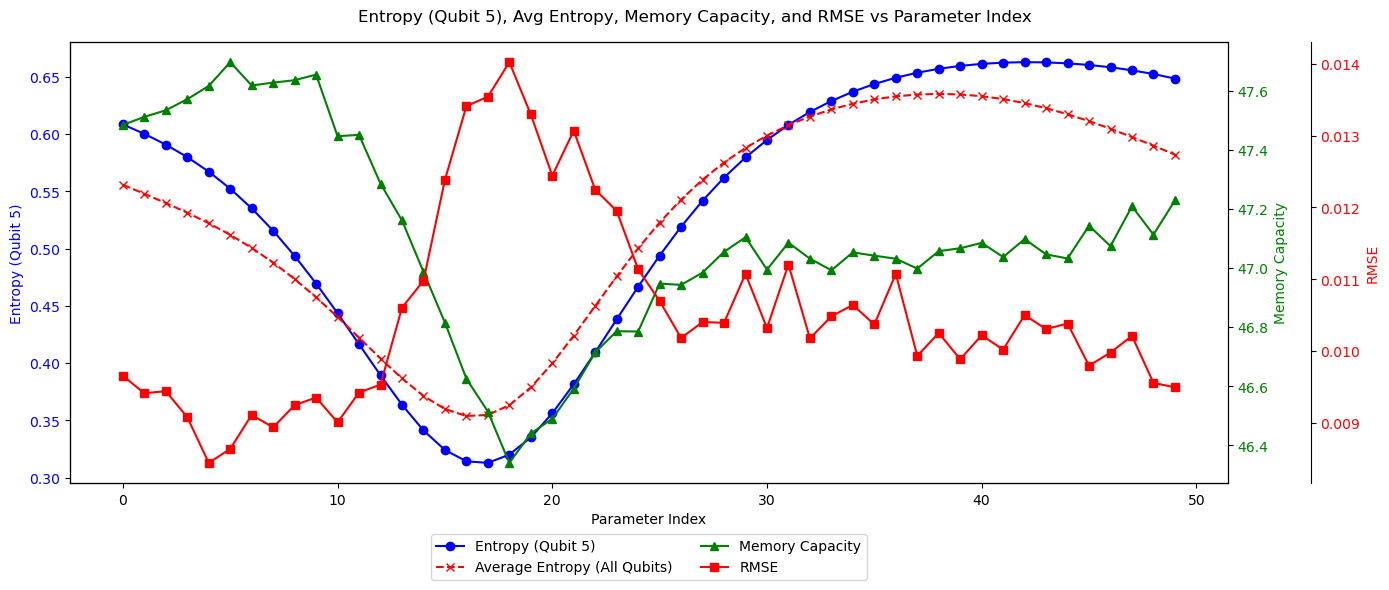

In [11]:
plot_mc_entropy_rmse_avg(MC, entropies, rmse, qubit_index=5)

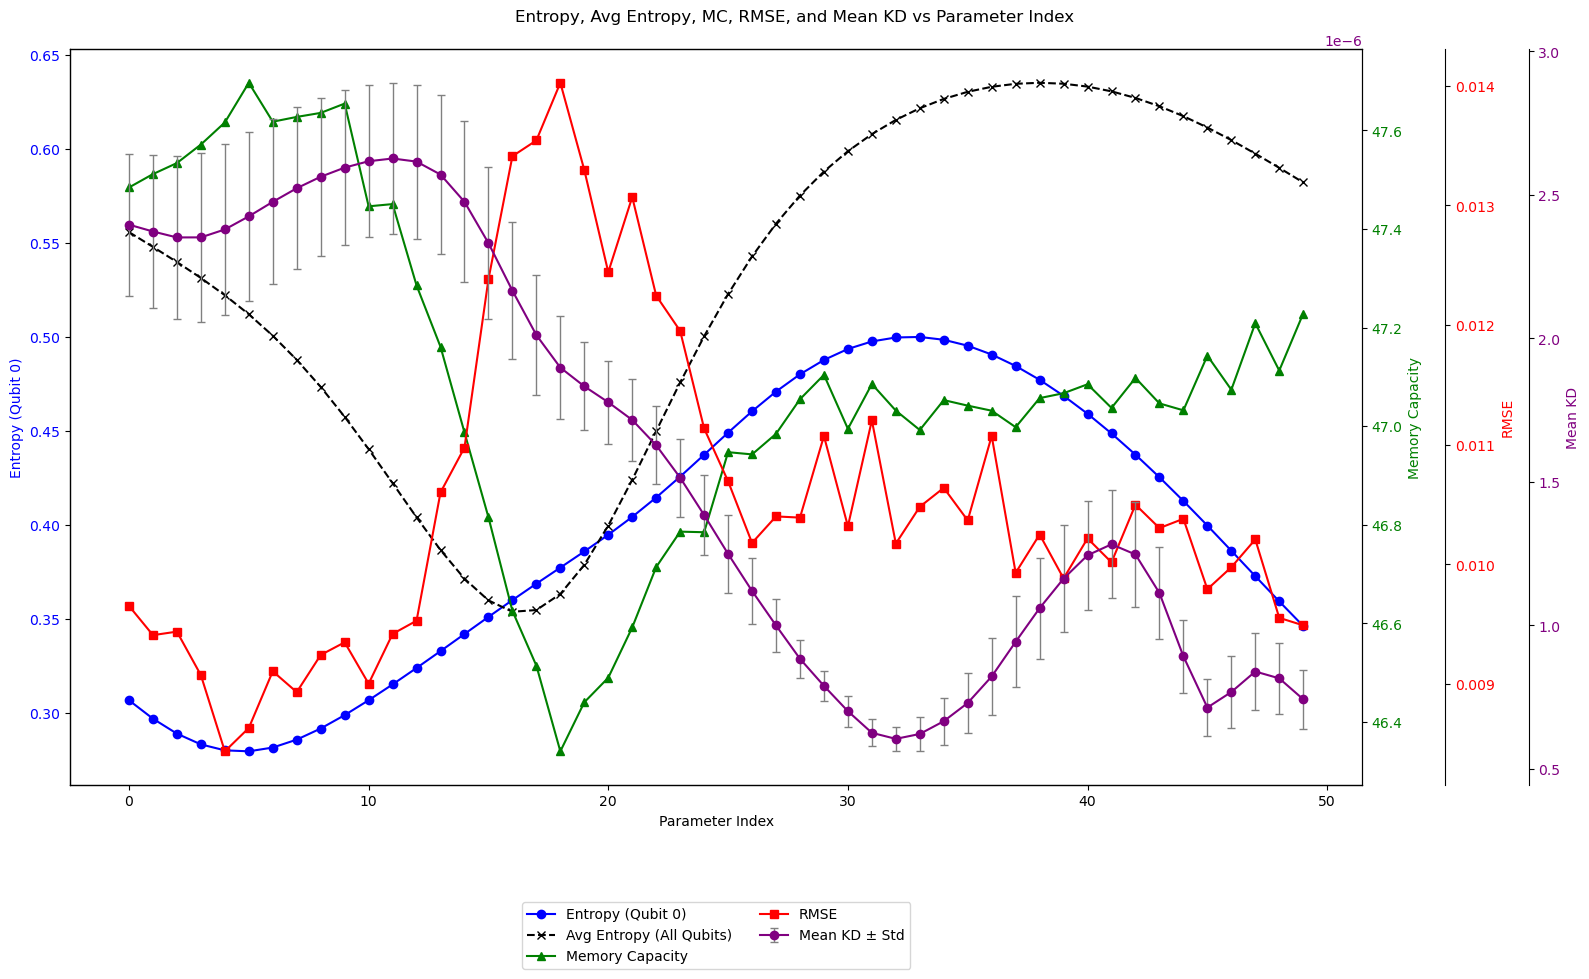

In [15]:
# Load KD values
kd_data = np.load("KD_values_50.npz")
KD_array = kd_data["KD"]  # Shape: (50, 50)

# Compute statistics
mean_kd = np.mean(KD_array, axis=0)
std_kd = np.std(KD_array, axis=0)
x = np.arange(len(mean_kd))

# Extended plot function including KD
def plot_full_metrics(MC, entropies, rmse, mean_kd, std_kd, qubit_index=0):
    MC = np.array(MC)
    rmse = np.array(rmse)
    entropy_values = np.array([e[qubit_index] for e in entropies])
    avg_entropy_values = np.array([np.mean(list(e.values())) for e in entropies])
    x_vals = np.arange(len(MC))

    fig, ax1 = plt.subplots(figsize=(16, 10))

    # Entropy
    ax1.set_xlabel("Parameter Index")
    ax1.set_ylabel(f"Entropy (Qubit {qubit_index})", color='blue')
    ax1.plot(x_vals, entropy_values, 'o-', color='blue', label=f'Entropy (Qubit {qubit_index})')
    ax1.plot(x_vals, avg_entropy_values, 'x--', color='black', label='Avg Entropy (All Qubits)')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Memory Capacity
    ax2 = ax1.twinx()
    ax2.set_ylabel("Memory Capacity", color='green')
    ax2.plot(x_vals, MC, '^-', color='green', label='Memory Capacity')
    ax2.tick_params(axis='y', labelcolor='green')

    # RMSE
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.set_ylabel("RMSE", color='red')
    ax3.plot(x_vals, rmse, 's-', color='red', label='RMSE')
    ax3.tick_params(axis='y', labelcolor='red')

    # KD plot (fourth axis on top)
    ax4 = ax1.twinx()
    ax4.spines['right'].set_position(('outward', 120))
    ax4.set_ylabel("Mean KD", color='purple')
    ax4.errorbar(x, mean_kd, yerr=std_kd, fmt='o-', color='purple', ecolor='gray', elinewidth=1, capsize=3, label='Mean KD ± Std')
    ax4.tick_params(axis='y', labelcolor='purple')

    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    lines4, labels4 = ax4.get_legend_handles_labels()
    ax1.legend(lines1 + lines2 + lines3 + lines4, labels1 + labels2 + labels3 + labels4, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

    fig.suptitle(f"Entropy, Avg Entropy, MC, RMSE, and Mean KD vs Parameter Index")
    fig.tight_layout()
    plt.show()

# Call the extended plot function
plot_full_metrics(MC, entropies, rmse, mean_kd, std_kd, qubit_index=0)


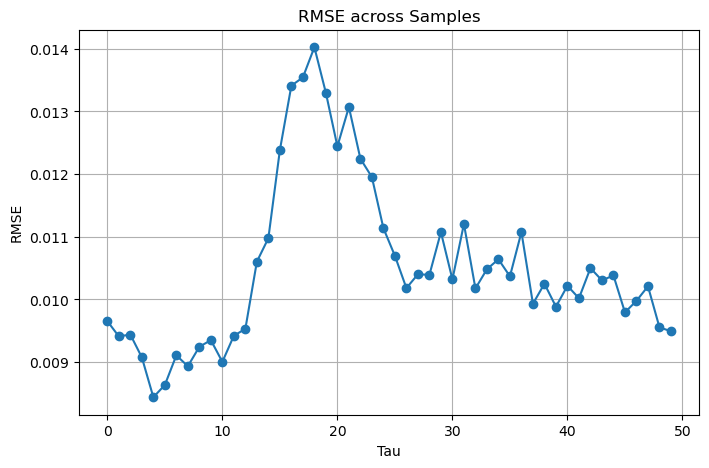

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(rmse, marker='o')
plt.xlabel("Tau")
plt.ylabel("RMSE")
plt.title("RMSE across Samples")
plt.grid(True)
plt.show()

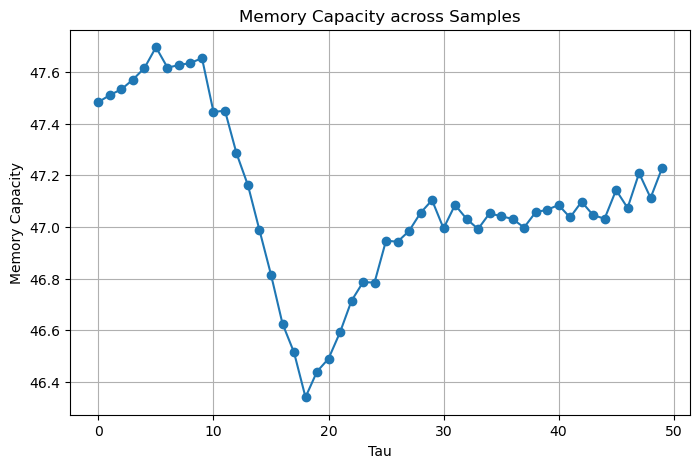

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(MC, marker='o')
plt.xlabel("Tau")
plt.ylabel("Memory Capacity")
plt.title("Memory Capacity across Samples")
plt.grid(True)
plt.show()

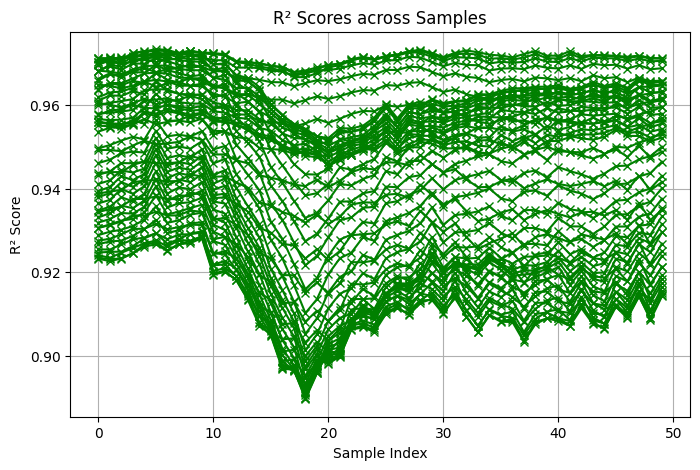

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(R2, marker='x', color='green')
plt.xlabel("Sample Index")
plt.ylabel("R² Score")
plt.title("R² Scores across Samples")
plt.grid(True)
plt.show()

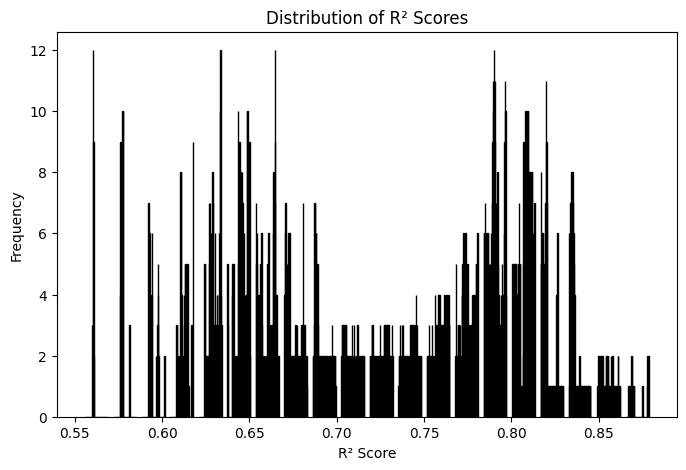

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(R2, bins=20, edgecolor='black')
plt.xlabel("R² Score")
plt.ylabel("Frequency")
plt.title("Distribution of R² Scores")
plt.show()

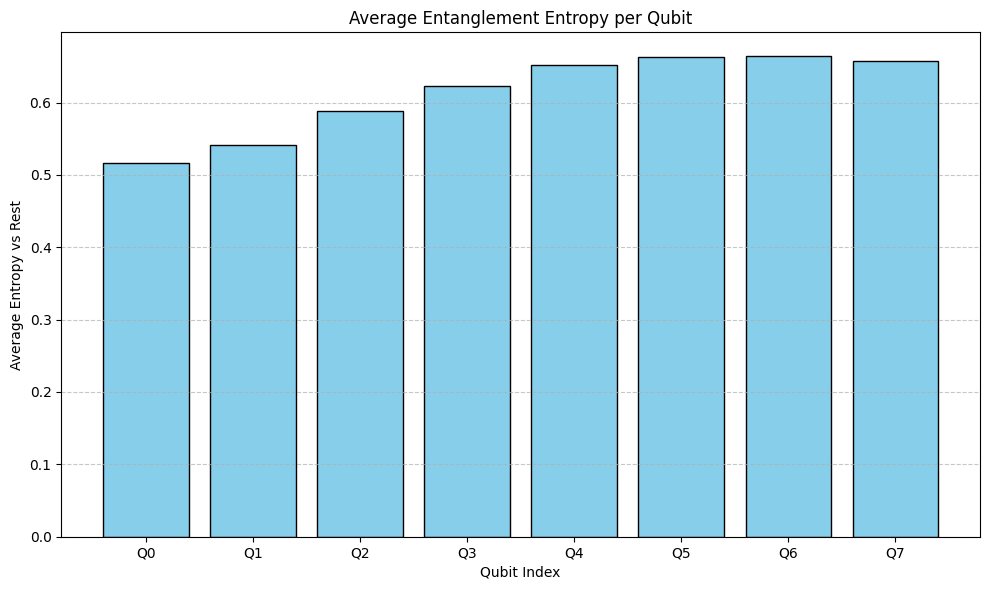

In [14]:
import matplotlib.pyplot as plt
import json

# # Load the saved JSON data
# with open("entropies_results.json", "r") as f:
#     data = json.load(f)

avg_entropy = data["average_entropy"]

# Prepare data for plotting
qubits = list(avg_entropy.keys())
values = list(avg_entropy.values())

# Plot average entropy per qubit
plt.figure(figsize=(10, 6))
plt.bar(qubits, values, color='skyblue', edgecolor='black')
plt.xlabel("Qubit Index")
plt.ylabel("Average Entropy vs Rest")
plt.title("Average Entanglement Entropy per Qubit")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
entropies

[{0: np.float64(0.3066658495450225),
  1: np.float64(0.39570623015621714),
  2: np.float64(0.5069434587889544),
  3: np.float64(0.5225880032176826),
  4: np.float64(0.5407814866059716),
  5: np.float64(0.6083469681444269),
  6: np.float64(0.5983497023518223),
  7: np.float64(0.6166884226297431),
  8: np.float64(0.6519953584181608),
  9: np.float64(0.6627421812072841),
  10: np.float64(0.6374571463862144),
  11: np.float64(0.6192638491368655)},
 {0: np.float64(0.2968654831764533),
  1: np.float64(0.38367302541794857),
  2: np.float64(0.4969332576071578),
  3: np.float64(0.5123168907382145),
  4: np.float64(0.5331272785419172),
  5: np.float64(0.6001247036901614),
  6: np.float64(0.5896882668892729),
  7: np.float64(0.6075878170672284),
  8: np.float64(0.6478149996583152),
  9: np.float64(0.6565716136799502),
  10: np.float64(0.6310311011371691),
  11: np.float64(0.6174780917100086)},
 {0: np.float64(0.2889127854735917),
  1: np.float64(0.3717886327478482),
  2: np.float64(0.485095710040

In [66]:
from qiskit.circuit import QuantumCircuit
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, entropy
from qiskit.quantum_info import concurrence
import numpy as np
counts=[]
conc=[]
for i in range(itr):
    p = [vals[i],0.1, 0.11106640694509373]
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.h(1)
    qc.rz(-np.pi/2,1)
    qc.cx(1,0)
    qc.rz(p[0],0)
    qc.ry(p[1],1)
    qc.cx(0,1)
    qc.ry(p[2],1)
    qc.cx(1,0)
    qc.rz(np.pi/2,0)
    state = Statevector.from_instruction(qc)
    rho = DensityMatrix(state)
    C = concurrence(rho)
    conc.append(C)
    qc.measure_all()
    sampler = Sampler()
    res = sampler.run([qc]).result()
    counts_ = res[0].data.meas.get_counts() 
    fid = counts_.values()
    counts.append(counts_)

In [70]:
np.argmin(conc)

np.int64(53)

In [67]:
conc[53]

np.float64(8.859477709653315e-13)

In [71]:
vals[53]

np.float64(0.11106640694509373)

In [68]:
counts

[{'00': 239, '10': 262, '11': 273, '01': 250},
 {'11': 258, '00': 278, '10': 242, '01': 246},
 {'01': 265, '10': 231, '00': 251, '11': 277},
 {'01': 243, '10': 240, '00': 290, '11': 251},
 {'00': 266, '10': 277, '11': 236, '01': 245},
 {'11': 280, '10': 255, '01': 237, '00': 252},
 {'00': 270, '01': 244, '10': 232, '11': 278},
 {'00': 258, '11': 269, '10': 234, '01': 263},
 {'10': 273, '00': 247, '01': 244, '11': 260},
 {'10': 256, '00': 246, '11': 258, '01': 264},
 {'00': 265, '11': 270, '01': 239, '10': 250},
 {'01': 248, '10': 267, '00': 251, '11': 258},
 {'01': 260, '00': 262, '11': 273, '10': 229},
 {'00': 265, '11': 253, '01': 265, '10': 241},
 {'00': 281, '10': 227, '01': 270, '11': 246},
 {'00': 261, '10': 256, '11': 270, '01': 237},
 {'01': 243, '00': 266, '10': 237, '11': 278},
 {'01': 233, '10': 277, '00': 271, '11': 243},
 {'00': 268, '01': 261, '10': 232, '11': 263},
 {'11': 273, '01': 256, '00': 252, '10': 243},
 {'10': 227, '01': 251, '00': 273, '11': 273},
 {'10': 254, 

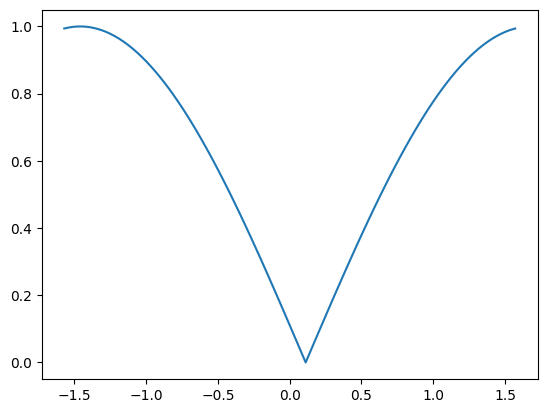

In [69]:
import matplotlib.pyplot as plt
plt.plot(vals, conc)

In [11]:
from qiskit.quantum_info import Statevector, partial_trace, entropy
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
itr = 5
a = -1.4746251231135765
b = 1.47
vals = np.linspace(a, b, itr)
ent_entropy = []

for i in tqdm(range(itr), desc="Sweeping entangling parameter"):
    CP_val = vals[i]
    
    # To accumulate entropy for each cut size across all X_train
    cut_entropies = None  # Will be initialized with correct shape later
    
    for j in range(len(X_train)):
        d = X_train[j]
        CP_params = [CP_val, np.pi/7, -np.pi/3, 7*np.pi/7, np.pi/9, -np.pi/7]
        qc = CPCircuit(num_features=window_size, reps=1, CP_params=CP_params).CPMap().assign_parameters(d)
        state = Statevector.from_instruction(qc)
        
        num_qubits = qc.num_qubits
        current_entropies = []

        for cut_size in range(1, num_qubits):
            qubits_A = list(range(cut_size))
            qubits_B = list(range(cut_size, num_qubits))
            rho_A = partial_trace(state, qubits_B)
            S = entropy(rho_A, base=2)
            current_entropies.append(S)

        # Initialize or accumulate
        if cut_entropies is None:
            cut_entropies = np.array(current_entropies)
        else:
            cut_entropies += np.array(current_entropies)

    # Average over all X_train[j]
    cut_entropies /= len(X_train)
    ent_entropy.append(cut_entropies.tolist())

Sweeping entangling parameter: 100%|██████████████| 5/5 [01:30<00:00, 18.05s/it]


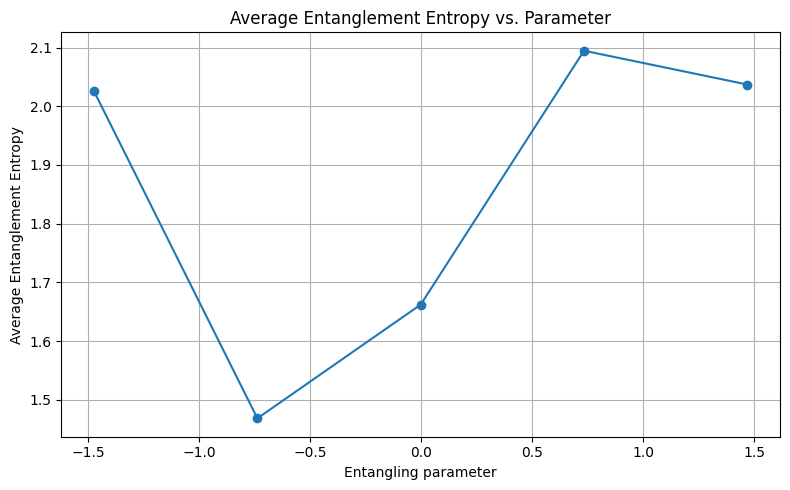

In [13]:
avg_entropy = np.mean(ent_entropy, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(vals, avg_entropy, marker='o')
plt.xlabel("Entangling parameter")
plt.ylabel("Average Entanglement Entropy")
plt.title("Average Entanglement Entropy vs. Parameter")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import json

# Extracted entropy data for each run (manually parsed from your message)
entropy_data = [
    {"Q0": 0.5390, "Q1": 0.5540, "Q2": 0.6041, "Q3": 0.6443, "Q4": 0.6641, "Q5": 0.6901, "Q6": 0.6795, "Q7": 0.6722},
    {"Q0": 0.5349, "Q1": 0.5508, "Q2": 0.6018, "Q3": 0.6410, "Q4": 0.6636, "Q5": 0.6873, "Q6": 0.6779, "Q7": 0.6719},
    {"Q0": 0.5302, "Q1": 0.5477, "Q2": 0.5994, "Q3": 0.6376, "Q4": 0.6631, "Q5": 0.6837, "Q6": 0.6763, "Q7": 0.6713},
    # Add the remaining entries similarly
]

# Compute average entropy per qubit across all entries
avg_entropy = {}
num_entries = len(entropy_data)

for q in entropy_data[0].keys():
    avg_entropy[q] = sum(run[q] for run in entropy_data) / num_entries

# Combine data into a JSON structure
result = {
    "entropies": entropy_data,
    "average_entropy": avg_entropy
}

# Save to JSON file
with open("entropies_results.json", "w") as f:
    json.dump(result, f, indent=4)

result  # Display result as confirmation


In [1]:
import pickle

with open("results_alpha_0_1.pkl", "rb") as f:
    data = pickle.load(f)

qstates = data["qstates"]
MC = data["MC"]
R2 = data["R2"]
entropies = data["entropies"]
rmse = data["MSE"]

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    # ── Font ──────────────────────────────────────────────────
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size":          12,          # base size for tick labels
    "axes.titlesize":     14,          # subplot title
    "axes.labelsize":     13,          # x/y axis labels
    "legend.fontsize":    11,
    "xtick.labelsize":    11,
    "ytick.labelsize":    11,

    # ── Line thickness ────────────────────────────────────────
    "lines.linewidth":    2.5,         # matches the chart line width
    "lines.markersize":   8,           # matches marker size

    # ── Axes ──────────────────────────────────────────────────
    "axes.linewidth":     1.2,
    "axes.spines.top":    False,       # clean look — no top/right border
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.3,
    "grid.linewidth":     0.6,

    # ── Ticks ─────────────────────────────────────────────────
    "xtick.major.width":  1.2,
    "ytick.major.width":  1.2,
    "xtick.major.size":   5,
    "ytick.major.size":   5,
    "xtick.direction":    "out",
    "ytick.direction":    "out",

    # ── Figure / output ───────────────────────────────────────
    "figure.dpi":         150,         # screen preview
    "savefig.dpi":        300,         # print/paper quality
    "savefig.bbox":       "tight",
    "savefig.format":     "pdf",       # vector — best for papers
})

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def plot_mc_entropy_rmse_avg(MC, entropies, mse, qubit_index=0):
    MC = np.array(MC)
    mse = np.array(mse)
    entropy_values = np.array([e[qubit_index] for e in entropies])
    avg_entropy_values = np.array([np.mean(list(e.values())) for e in entropies])
    x = np.arange(len(MC))

    # Using the colorblind-friendly palette from before
    color_entropy = '#0173b2' # Blue
    color_mc = '#de8f05'      # Orange
    color_mse = '#029e73'     # Green

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # --- Axes base styling ---
    ax1.grid(True, which='both', axis='both', linestyle='--', linewidth=0.7)

    ax1.spines['top'].set_visible(True)  
    ax1.spines['top'].set_color('black') 
    ax1.spines['top'].set_linewidth(1.0)
    # --- Series 1: Average entropy (Left Axis) ---
    ax1.set_xlabel("Parameter Index")
    ax1.set_ylabel("Average Entropy (All Qubits)", color=color_entropy)
    l1, = ax1.plot(
        x, avg_entropy_values,
        linestyle='--', linewidth=1.6,
        marker='x', markersize=5,
        color=color_entropy, label='Average Entropy (All Qubits)'
    )
    ax1.tick_params(axis='y', labelcolor=color_entropy)

    # --- Series 2: Memory Capacity (Right Axis) ---
    ax2 = ax1.twinx()
    ax2.spines['right'].set_visible(True)  
    ax2.spines['right'].set_color(color_mc)
    ax2.spines['right'].set_linewidth(1.1) # Match your default line weight

    ax2.set_ylabel("Memory Capacity", color=color_mc)
    l2, = ax2.plot(
        x, MC,
        linestyle='-', linewidth=1.6,
        marker='^', markersize=5,
        color=color_mc, label='Memory Capacity'
    )
    ax2.tick_params(axis='y', labelcolor=color_mc)
    ax2.spines['right'].set_color(color_mc)

    # --- Series 3: MSE (Second Right Axis) ---
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.spines['right'].set_visible(True)  
    ax3.spines['right'].set_color(color_mse)
    ax3.spines['right'].set_linewidth(1.1)

    ax3.spines['right'].set_position(('outward', 60))
    ax3.set_ylabel("MSE", color=color_mse)
    l3, = ax3.plot(
        x, mse,
        linestyle='-', linewidth=1.8,
        marker='s', markersize=5,
        color=color_mse, label='MSE'
    )
    ax3.tick_params(axis='y', labelcolor=color_mse)
    ax3.spines['right'].set_color(color_mse)

    # --- Annotations ---
    max_mse_idx = np.argmax(mse)
    min_mc_idx = np.argmin(MC)

    ax2.annotate(
        f'Min MC:\n({min_mc_idx}, {MC[min_mc_idx]:.2f})',
        xy=(min_mc_idx, MC[min_mc_idx]),
        xytext=(min_mc_idx + 2, MC[min_mc_idx] + 0.081),
        arrowprops=dict(arrowstyle="->", color=color_mc, linewidth=1.0),
        color=color_mc
    )

    ax3.annotate(
        f'Max MSE:\n({max_mse_idx}, {mse[max_mse_idx]:.4f})',
        xy=(max_mse_idx, mse[max_mse_idx]),
        xytext=(max_mse_idx + 2, mse[max_mse_idx] - 0.0005),
        arrowprops=dict(arrowstyle="->", color=color_mse, linewidth=1.0),
        color=color_mse
    )

    # --- Legend ---
    lines = [l1, l2, l3]
    labels = [ln.get_label() for ln in lines]
    ax1.legend(
        lines, labels,
        loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3,
        frameon=True # Set to True if you want the box we discussed earlier
    )

    fig.tight_layout()
    plt.savefig("paper_results/figures/entropy_memory_rmse.pdf", bbox_inches='tight')
    plt.show()


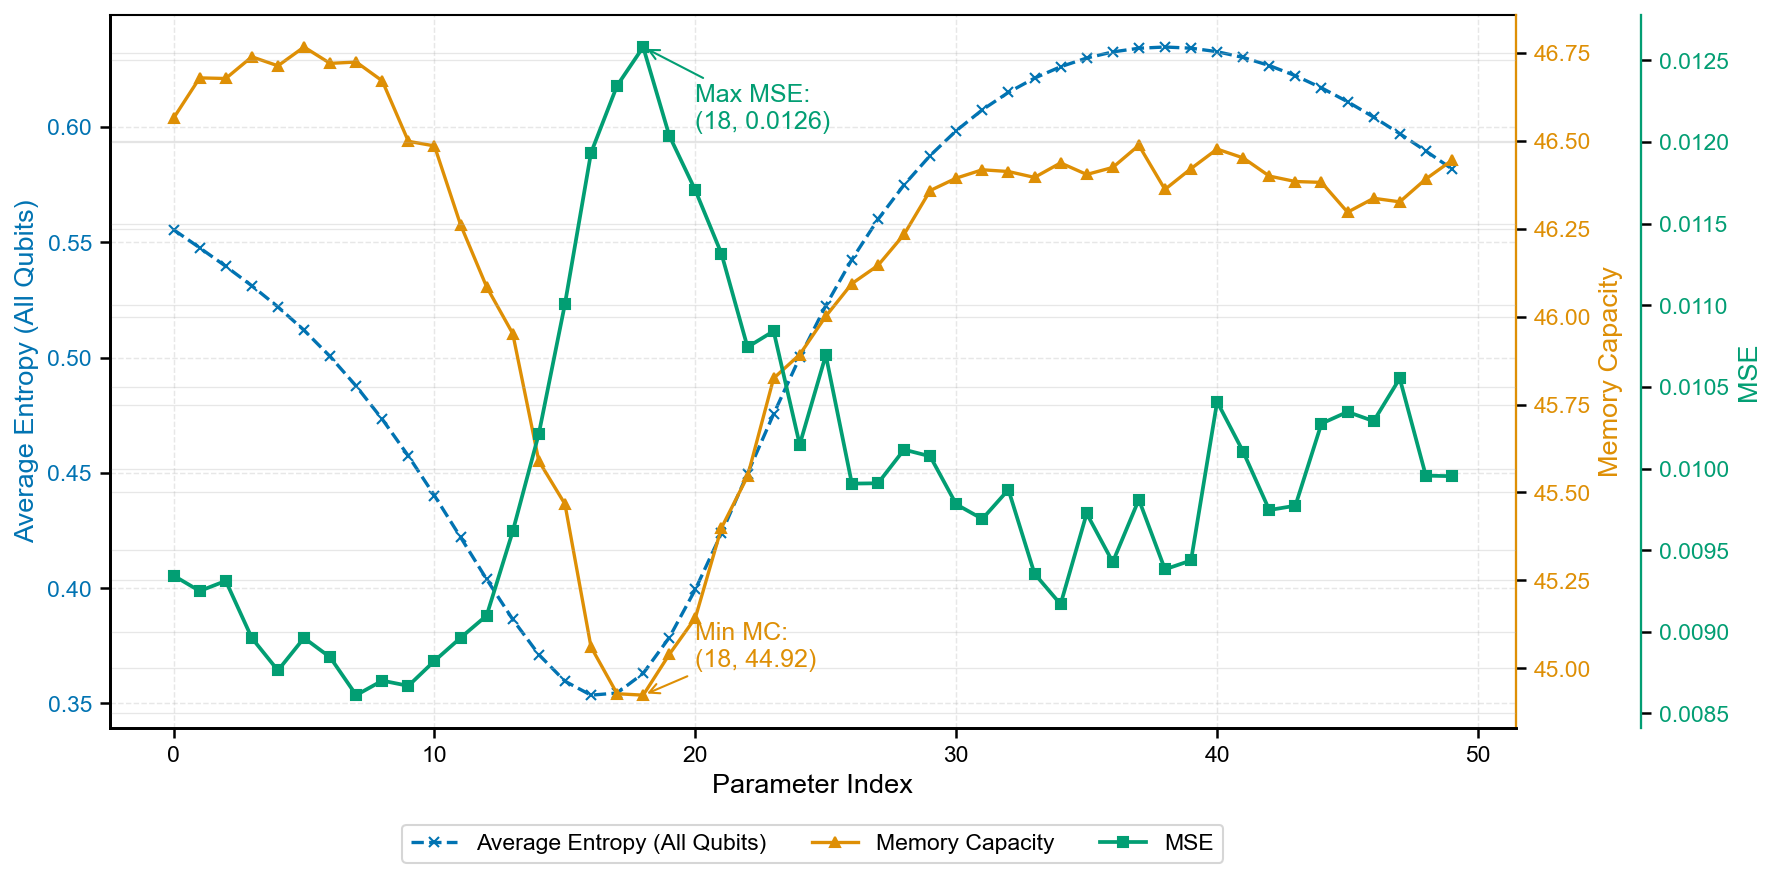

In [22]:
plot_mc_entropy_rmse_avg(MC, entropies, rmse, qubit_index=4)

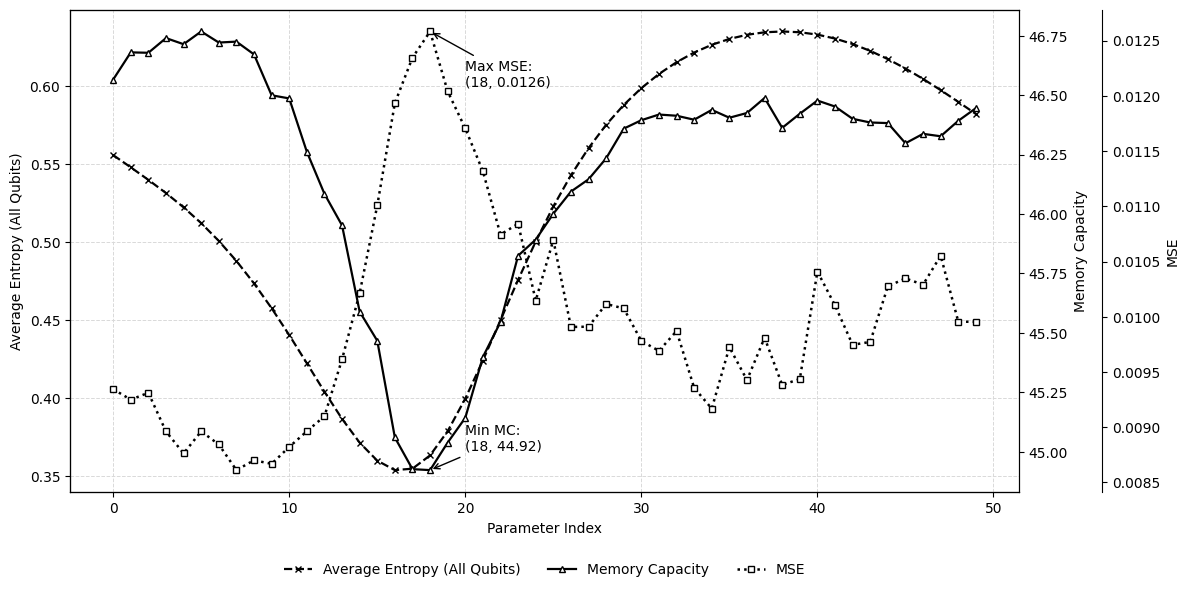

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def plot_mc_entropy_rmse_avg(MC, entropies, mse, qubit_index=0):
    MC = np.array(MC)
    mse = np.array(mse)
    entropy_values = np.array([e[qubit_index] for e in entropies])
    avg_entropy_values = np.array([np.mean(list(e.values())) for e in entropies])
    x = np.arange(len(MC))

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # --- Axes base styling (grayscale) ---
    for ax in (ax1,):
        ax.tick_params(axis='both', colors='0.0')
        ax.spines['bottom'].set_color('0.0')
        ax.spines['left'].set_color('0.0')
    ax1.grid(True, which='both', axis='both', linestyle='--', linewidth=0.7, color='0.85')

    # --- Series 1: Average entropy (left axis, dashed, x-marker) ---
    ax1.set_xlabel("Parameter Index", color='0.0')
    ax1.set_ylabel("Average Entropy (All Qubits)", color='0.0')
    l1, = ax1.plot(
        x, avg_entropy_values,
        linestyle='--', linewidth=1.6,
        marker='x', markersize=5,
        color='0.0', label='Average Entropy (All Qubits)'
    )
    ax1.tick_params(axis='y', labelcolor='0.0')

    # --- Series 2: Memory Capacity (right axis, solid, triangle marker) ---
    ax2 = ax1.twinx()
    for side in ('right',):
        ax2.spines[side].set_color('0.0')
    ax2.set_ylabel("Memory Capacity", color='0.0')
    l2, = ax2.plot(
        x, MC,
        linestyle='-', linewidth=1.6,
        marker='^', markersize=5,
        markerfacecolor='1.0', markeredgecolor='0.0',
        color='0.0', label='Memory Capacity'
    )
    ax2.tick_params(axis='y', labelcolor='0.0')

    # --- Series 3: MSE (second right axis, dotted, square marker) ---
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.spines['right'].set_color('0.0')
    ax3.set_ylabel("MSE", color='0.0')
    l3, = ax3.plot(
        x, mse,
        linestyle=':', linewidth=1.8,
        marker='s', markersize=5,
        markerfacecolor='1.0', markeredgecolor='0.0',
        color='0.0', label='MSE'
    )
    ax3.tick_params(axis='y', labelcolor='0.0')

    # --- Annotations (black arrows/text) ---
    max_mse_idx = np.argmax(mse)
    min_mc_idx = np.argmin(MC)

    ax2.annotate(
        f'Min MC:\n({min_mc_idx}, {MC[min_mc_idx]:.2f})',
        xy=(min_mc_idx, MC[min_mc_idx]),
        xytext=(min_mc_idx + 2, MC[min_mc_idx] + 0.081),
        arrowprops=dict(arrowstyle="->", color='0.0', linewidth=1.0),
        fontsize=10, color='0.0'
    )

    ax3.annotate(
        f'Max MSE:\n({max_mse_idx}, {mse[max_mse_idx]:.4f})',
        xy=(max_mse_idx, mse[max_mse_idx]),
        xytext=(max_mse_idx + 2, mse[max_mse_idx] - 0.0005),
        arrowprops=dict(arrowstyle="->", color='0.0', linewidth=1.0),
        fontsize=10, color='0.0'
    )

    # --- Legend (combined, monochrome) ---
    lines = [l1, l2, l3]
    labels = [ln.get_label() for ln in lines]
    ax1.legend(
        lines, labels,
        loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3,
        frameon=False
    )

    fig.tight_layout()
    plt.savefig("Paper_results/figures/bw_entropy_memory_rmse_bw.pdf", bbox_inches='tight')
    plt.show()

# Example call:
plot_mc_entropy_rmse_avg(MC, entropies, rmse, qubit_index=4)
